In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

# Đọc dữ liệu từ file csv

In [18]:
# Đọc dữ liệu từ file csv
merged_df = pd.read_csv("../DATA EXPLORER CONTEST/Preprocessed_Data/merged_data_(t-1).csv")

In [19]:
# Loại bỏ dòng trống
merged_df.dropna(inplace=True)

In [20]:
# Đặt cột Date làm index
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.set_index('Date', inplace=True)

# Đặt Feature và Target

In [ ]:
# --- Lấy các cột cần thiết ---
features = ['Market Cap_lag1','Closing Price_lag1','Remaining Room %_lag1','Total Sell Value_lag1',
            'Matched Sell Value_lag1','Matched Buy Value_lag1',
            'Negotiated Sell Value_lag1','Negotiated Sell Volume_lag1',
            'Negotiated Buy Value_lag1','Market Cap_lag1','Foreign Investor Room_lag1','MA5','MA10']
target = 'Closing Price'

# Chia bộ dữ liệu Train/Test theo tỷ lệ 80/20 và chuẩn hóa dữ liệu

In [77]:
# Sắp xếp dữ liệu theo thời gian trước
merged_df = merged_df.sort_index()

# Tách thủ công theo thời gian: 80% train, 20% test
split_index = int(len(merged_df) * 0.8)
train_df = merged_df.iloc[:split_index]
test_df = merged_df.iloc[split_index:]

# Lấy X và y
X_train_raw = train_df[features]
y_train = train_df[target]

X_test_raw = test_df[features]
y_test = test_df[target]

# Lưu lại index (thời gian)
train_index = X_train_raw.index
test_index = X_test_raw.index



In [78]:
# --- Chuẩn hóa dữ liệu ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


# Mô hình Linear Regression

In [79]:
# --- Xây mô hình ---
model = LinearRegression()
model.fit(X_train, y_train,)

# --- Dự đoán ---
y_pred = model.predict(X_test)


In [80]:
# Tạo DataFrame để dễ thao tác và sắp xếp
train_df = pd.DataFrame({'Giá huấn luyện': y_train}, index=train_index).sort_index()
test_df = pd.DataFrame({'Giá thực tế': y_test, 'Giá dự đoán': y_pred}, index=test_index).sort_index()

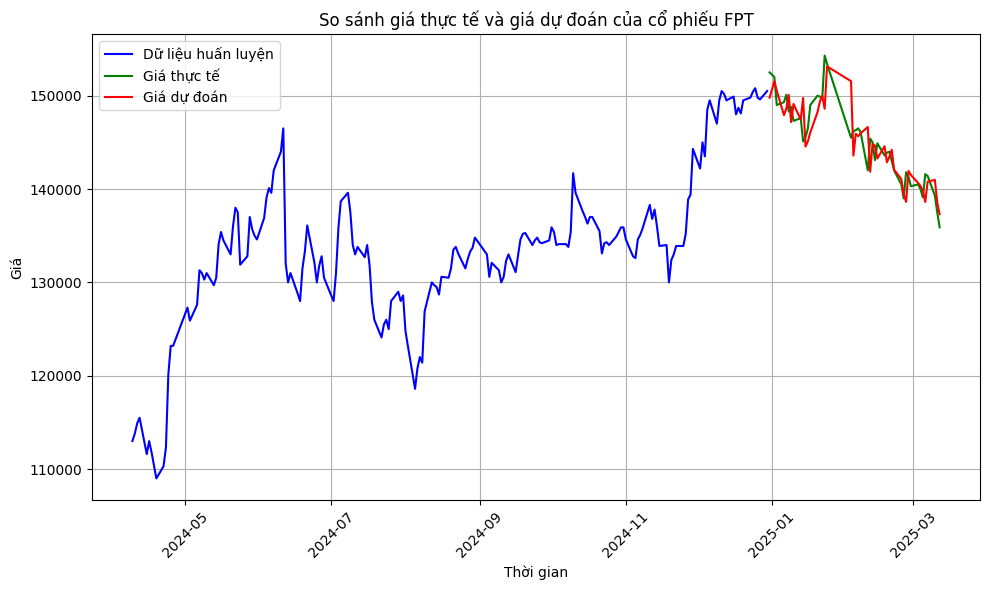

In [81]:
plt.figure(figsize=(10, 6))
plt.plot(train_df.index, train_df['Giá huấn luyện'], label='Dữ liệu huấn luyện', color='blue')
plt.plot(test_df.index, test_df['Giá thực tế'], label='Giá thực tế', color='green')
plt.plot(test_df.index, test_df['Giá dự đoán'], label='Giá dự đoán', color='red')

plt.legend()
plt.title('So sánh giá thực tế và giá dự đoán của cổ phiếu FPT')
plt.xlabel('Thời gian')
plt.ylabel('Giá')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [84]:
# In ra các giá trị dự đoán
print("Giá thực tế và giá dự đoán:")
print(test_df[['Giá thực tế', 'Giá dự đoán']])

Giá thực tế và giá dự đoán:
            Giá thực tế    Giá dự đoán
Date                                  
2024-12-31       152500  149780.674994
2025-01-02       152000  151546.934377
2025-01-03       149000  150534.995287
2025-01-06       149300  147912.567746
2025-01-07       150100  148634.238919
2025-01-08       148300  150094.552679
2025-01-09       148800  147175.001965
2025-01-10       147300  149115.068977
2025-01-13       147600  147432.923453
2025-01-14       145100  149762.482417
2025-01-15       145500  144549.378455
2025-01-16       146500  145110.883199
2025-01-17       149000  146066.453183
2025-01-20       150000  148226.036724
2025-01-21       149900  149369.588085
2025-01-22       149700  149991.280644
2025-01-23       154300  148601.442861
2025-01-24       153400  153140.532647
2025-02-03       145500  151556.789860
2025-02-04       146200  143590.246864
2025-02-05       146300  145915.693826
2025-02-06       146500  145657.380189
2025-02-07       146100  145980.1877

In [85]:
# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 4522080.90
Root Mean Squared Error (RMSE): 2126.52
Mean Absolute Error (MAE): 1560.10
R² Score: 0.76
